p_true,  R_nat,  E[R(W)],  upper bound
 0.01,  0.6160,  0.0155,  0.0565
 0.03,  0.5538,  0.0326,  0.0892
 0.05,  0.4908,  0.0531,  0.1109
 0.08,  0.4128,  0.0823,  0.1377
 0.10,  0.3749,  0.0991,  0.1547
 0.15,  0.2736,  0.1517,  0.2109
 0.20,  0.1907,  0.2055,  0.2619
 0.25,  0.1348,  0.2507,  0.3056
 0.30,  0.0858,  0.3020,  0.3589
 0.35,  0.0514,  0.3492,  0.4012
 0.40,  0.0230,  0.4047,  0.4529
 0.45,  0.0091,  0.4469,  0.4874


 0.49,  0.0036,  0.4694,  0.4994


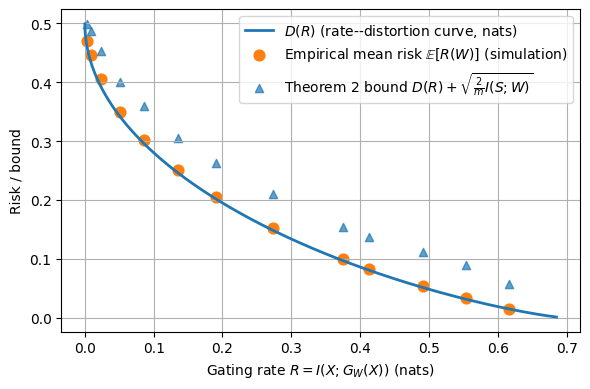

In [ ]:


import numpy as np
import math
import random
import matplotlib.pyplot as plt

def binary_entropy_nat(p):
    """Binary entropy h(p) in NATS (natural logarithm)."""
    if p <= 0.0 or p >= 1.0:
        return 0.0
    return -p * math.log(p) - (1.0 - p) * math.log(1.0 - p)

def R_of_D_nat(D):
    """
    Rate–distortion function for Bern(1/2) with Hamming distortion, in NATS:
        R(D) = log(2) - h(D),
    where h is binary entropy in nats and D in [0, 0.5].
    """
    return math.log(2.0) - binary_entropy_nat(D)

def D_of_R_nat(R_nat, tol=1e-8):
    """
    Inverse of R(D) = log(2) - h(D), all in nats.
    Given R_nat in [0, log 2], return D in [0, 0.5] such that R(D) ≈ R_nat.
    """
    if R_nat <= 0.0:
        return 0.5
    if R_nat >= math.log(2.0):
        return 0.0

    target_h = math.log(2.0) - R_nat
    lo, hi = 0.0, 0.5
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        h = binary_entropy_nat(mid)
        if h < target_h:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

def simulate_for_one_p_true_nats(
    p_true,
    p_list,
    m=200,
    T=1.0,
    n_datasets=400,
    seed=0
):
    """
    For a fixed true BSC(p_true), run n_datasets Monte Carlo datasets,
    learn W via tempered posterior over candidate channels p_list, and estimate:
      - I(S;W) in nats
      - average gating rate R_gate_nat = E[I(X;G_W(X))] in nats
      - average population risk E[R(W)] (denoted R_pop_mean)
    """

    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed + 123)

    posteriors = []
    risks = []
    gating_rates_nat = []

    for _ in range(n_datasets):

        X = np_rng.binomial(1, 0.5, size=m)
        noise_true = np_rng.binomial(1, p_true, size=m)
        Y = X ^ noise_true

        mismatches = int(np.sum(X != Y))
        ll = []
        for p in p_list:
            p_safe = min(max(p, 1e-12), 1.0 - 1e-12)
            ll_r = mismatches * math.log(p_safe) + (m - mismatches) * math.log(1.0 - p_safe)
            ll.append(ll_r)


        max_ll = max(ll)
        exps = [math.exp((l - max_ll) / T) for l in ll]
        Z = sum(exps)
        q = [e / Z for e in exps]
        posteriors.append(q)

        u = rng.random()
        cum = 0.0
        chosen_idx = 0
        for i, qi in enumerate(q):
            cum += qi
            if u <= cum:
                chosen_idx = i
                break

        p_w = p_list[chosen_idx]


        risks.append(p_w)


        gating_rates_nat.append(R_of_D_nat(p_w))

    posteriors = np.array(posteriors)


    p_marginal = posteriors.mean(axis=0)
    H_W = -sum(pr * math.log(pr) for pr in p_marginal if pr > 0.0)

    H_W_given_S = 0.0
    for q in posteriors:
        H_q = -sum(qi * math.log(qi) for qi in q if qi > 0.0)
        H_W_given_S += H_q
    H_W_given_S /= len(posteriors)

    I_SW_nat = H_W - H_W_given_S
    R_pop_mean = float(np.mean(risks))
    R_gate_nat_mean = float(np.mean(gating_rates_nat))

    return I_SW_nat, R_gate_nat_mean, R_pop_mean

def theorem2_full_range_empirical_nats(
    m=200,
    T=1.0,
    n_datasets=400,
    rng_seed=0
):
    p_values = [0.01, 0.03, 0.05, 0.08, 0.10, 0.15,
                0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.49]
    p_list = p_values[:]

    R_nat_points = []
    R_pop_points = []
    bound_points = []

    print("p_true,  R_nat,  E[R(W)],  upper bound")

    for i, p_true in enumerate(p_values):
        I_SW_nat, R_gate_nat_mean, R_pop_mean = simulate_for_one_p_true_nats(
            p_true=p_true,
            p_list=p_list,
            m=m,
            T=T,
            n_datasets=n_datasets,
            seed=rng_seed + i,
        )


        D_at_R = D_of_R_nat(R_gate_nat_mean)


        bound = D_at_R + math.sqrt(2.0 * I_SW_nat / m)

        R_nat_points.append(R_gate_nat_mean)
        R_pop_points.append(R_pop_mean)
        bound_points.append(bound)

        print(f"{p_true:5.2f}, {R_gate_nat_mean:7.4f}, "
              f"{R_pop_mean:7.4f}, {bound:7.4f}")

        if R_pop_mean > bound + 1e-6:
            print("  WARNING: empirical mean risk exceeds bound (MC noise)")

    return np.array(R_nat_points), np.array(R_pop_points), np.array(bound_points)


R_nat_pts, R_pop_pts, bound_pts = theorem2_full_range_empirical_nats(
    m=200,
    T=1.0,
    n_datasets=400,
    rng_seed=0,
)


p_grid = np.linspace(0.001, 0.499, 400)
R_curve_nat = np.array([R_of_D_nat(p) for p in p_grid])
D_curve = p_grid

idx = np.argsort(R_curve_nat)
R_curve_nat = R_curve_nat[idx]
D_curve = D_curve[idx]

plt.figure(figsize=(6, 4))

plt.plot(R_curve_nat, D_curve, label=r"$D(R)$ (rate--distortion curve, nats)", linewidth=2)

plt.scatter(
    R_nat_pts, R_pop_pts,
    color="tab:orange", s=60,
    label=r"Empirical mean risk $\mathbb{E}[R(W)]$ (simulation)",
)

plt.scatter(
    R_nat_pts, bound_pts,
    marker="^", color="tab:blue", s=35, alpha=0.7,
    label=r"Theorem 2 bound $D(R)+\sqrt{\frac{2}{m}I(S;W)}$",
)

plt.xlabel(r"Gating rate $R = I(X;G_W(X))$ (nats)")
plt.ylabel("Risk / bound")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("theorem2_full_range_empirical_nats.eps", format="eps", bbox_inches="tight")
plt.show()
